In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
DROP_COLS = [
    # Identifiers (not predictive)
    'game_id', 'season', 'home_team', 'away_team', 
    'home_team_abbrev', 'away_team_abbrev', 'matchup',
    
    # Target variable
    # 'home_win',
    # 'date'
    
    # Game outcome stats (only known AFTER the game - data leakage)
    'home_gf', 'away_gf', 'home_ga', 'away_ga', 'home_sog', 'away_sog',
    'home_faceoffwin_pct', 'away_faceoffwin_pct',
    'home_powerplays', 'away_powerplays', 'home_powerplay_pct', 'away_powerplay_pct',
    'home_pk', 'away_pk', 'home_pk_pct', 'away_pk_pct',
    'home_pims', 'away_pims', 'home_hits', 'away_hits',
    'home_blockedshots', 'away_blockedshots', 'home_takeaways', 'away_takeaways',
    'home_giveaways', 'away_giveaways',
    
    # Goalie stats from THIS game
    'home_save_pct', 'away_save_pct',
    'home_goalie_save_pct', 'away_goalie_save_pct',
    'home_goalie_ga', 'away_goalie_ga',
    'home_goalie_saves', 'away_goalie_saves',
    'home_goalie_evenStrengthShotsAgainst', 'away_goalie_evenStrengthShotsAgainst',
    'home_goalie_powerPlayShotsAgainst', 'away_goalie_powerPlayShotsAgainst',
    'home_goalie_shorthandedShotsAgainst', 'away_goalie_shorthandedShotsAgainst',
    'home_goalie_evenStrengthGoalsAgainst', 'away_goalie_evenStrengthGoalsAgainst',
    'home_goalie_powerPlayGoalsAgainst', 'away_goalie_powerPlayGoalsAgainst',
]


In [4]:
# list all of the columns
# temp_df = pd.read_csv("../scripts/generated/data/nhl_data.csv")

# print("All columns in the dataset: ", temp_df.columns.tolist())

In [5]:
HOME_TEAM_L5_COLS = [
    'home_gf_ewm', 'home_ga_ewm', 'home_sog_ewm',
    'home_wins_l5', 'home_win_pct_l5', 'home_powerplay_pct_ewm',
    'home_penalty_kill_pct_ewm', 'home_powerplays_l5', 'home_penalty_kills_l5',
    'home_faceoffwin_pct_ewm', 'home_pims_ewm', 'home_hits_ewm',
    'home_blockedshots_ewm', 'home_giveaways_ewm', 'home_takeaways_ewm',
]

AWAY_TEAM_L5_COLS = [
    'away_gf_ewm', 'away_ga_ewm', 'away_sog_ewm',
    'away_wins_l5', 'away_win_pct_l5', 'away_powerplay_pct_ewm',
    'away_penalty_kill_pct_ewm', 'away_powerplays_l5', 'away_penalty_kills_l5',
    'away_faceoffwin_pct_ewm', 'away_pims_ewm', 'away_hits_ewm',
    'away_blockedshots_ewm', 'away_giveaways_ewm', 'away_takeaways_ewm',
]

GOALIE_L5_COLS = [
    'home_goalie_save_pct_ewm', 'home_goalie_ga_ewm', 'home_goalie_saves_ewm',
    'home_goalie_ev_sa_ewm', 'home_goalie_pp_sa_ewm', 'home_goalie_sh_sa_ewm',
    'home_goalie_ev_ga_ewm', 'home_goalie_pp_ga_ewm', 
    'away_goalie_save_pct_ewm', 'away_goalie_ga_ewm', 'away_goalie_saves_ewm',
    'away_goalie_ev_sa_ewm', 'away_goalie_pp_sa_ewm', 'away_goalie_sh_sa_ewm',
    'away_goalie_ev_ga_ewm', 'away_goalie_pp_ga_ewm',
]

TEAM_GOALIE_PERFORMANCE = [
    'home_team_save_pct_ewm', 'away_team_save_pct_ewm',
]

SEASON_COLS = [
    'home_win_pct_season', 'away_win_pct_season',
    'home_home_win_pct', 'away_away_win_pct',
    'home_gf_per_game_season', 'away_gf_per_game_season',
    'home_pointPctg_season', 'away_pointPctg_season', 'pointPctg_diff',
]

DIFF_COLS = [
    'home_goal_diff_ewm', 'home_ga_diff_ewm', 'home_shot_diff_ewm',
]

STREAKS_AND_REST = [
    'home_win_streak', 'away_win_streak',
    'home_rest_days', 'away_rest_days',
    'home_goalie_rest_days', 'away_goalie_rest_days',
]

HEAD_TO_HEAD = [
    'home_h2h_wins', 'home_h2h_gf', 'away_h2h_wins', 
    'away_h2h_gf', 'home_h2h_wins_diff',
]

FEATURE_COLS = (
    HOME_TEAM_L5_COLS +
    AWAY_TEAM_L5_COLS +
    GOALIE_L5_COLS +
    TEAM_GOALIE_PERFORMANCE +
    SEASON_COLS +
    DIFF_COLS +
    STREAKS_AND_REST +
    HEAD_TO_HEAD
)


In [6]:
# =============================================================================
# 3. EXPLORE DATA
# =============================================================================

# Load data - UPDATE THIS PATH
filepath = "../scripts/generated/data/nhl_data.csv"
df = pd.read_csv(filepath)

print(f"\nDataset shape: {df.shape}")
print(f"Columns in dataset: {len(df.columns)}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")

# Check target distribution
print("\n" + "="*60)
print("TARGET VARIABLE DISTRIBUTION")
print("="*60)
print(df['home_win'].value_counts())
print(f"\nHome win percentage: {df['home_win'].mean():.2%}")


Dataset shape: (3936, 128)
Columns in dataset: 128
Date range: 2023-10-10 to 2026-04-16

TARGET VARIABLE DISTRIBUTION
home_win
1    2133
0    1803
Name: count, dtype: int64

Home win percentage: 54.19%


In [7]:
# =============================================================================
# 4. PREPARE FEATURES
# =============================================================================

# Check which features are available
available_features = [col for col in FEATURE_COLS if col in df.columns]
missing_features = [col for col in FEATURE_COLS if col not in df.columns]

print("\n" + "="*60)
print("FEATURE AVAILABILITY")
print("="*60)
print(f"Available features: {len(available_features)}/{len(FEATURE_COLS)}")

if missing_features:
    print(f"\nMissing features ({len(missing_features)}):")
    for feat in missing_features[:10]:
        print(f"  - {feat}")
    if len(missing_features) > 10:
        print(f"  ... and {len(missing_features) - 10} more")

# Prepare features and target
X = df[available_features].copy()
y = df['home_win'].copy()

# Keep date for splitting
dates = pd.to_datetime(df['date'])

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Check missing values
missing_counts = X.isnull().sum()
if missing_counts.sum() > 0:
    print(f"\nMissing values per feature:")
    print(missing_counts[missing_counts > 0])

# Handle missing values
print(f"\nMissing values before imputation: {X.isnull().sum().sum()}")

# X = X.dropna()

# # Fill with median
# X = X.fillna(X.median())

# # Handle any infinite values
# X = X.replace([np.inf, -np.inf], np.nan)
# X = X.fillna(X.median())

print(f"Missing values after imputation: {X.isnull().sum().sum()}")


FEATURE AVAILABILITY
Available features: 71/71

Features shape: (3936, 71)
Target shape: (3936,)

Missing values per feature:
home_wins_l5             51
home_win_pct_l5          51
home_powerplays_l5       51
home_penalty_kills_l5    51
away_wins_l5             45
away_win_pct_l5          45
away_powerplays_l5       45
away_penalty_kills_l5    45
dtype: int64

Missing values before imputation: 384
Missing values after imputation: 384


In [8]:
# shape
print(f"\nFinal features shape: {X.shape}")
print(f"Final target shape: {y.shape}")


Final features shape: (3936, 71)
Final target shape: (3936,)


In [9]:
# =============================================================================
# 5. SEASON-LEVEL EXPANDING WINDOW SETUP
# =============================================================================

print("\n" + "="*60)
print("SEASON-LEVEL DATA SPLIT")
print("="*60)

# Drop NaN rows and sort by date
non_missing_idx = X.dropna().index
X_clean = X.loc[non_missing_idx]
y_clean = y.loc[non_missing_idx]
dates_clean = dates.loc[non_missing_idx]
season_clean = df['season'].loc[non_missing_idx]

sorted_idx = dates_clean.sort_values().index
X_sorted = X_clean.loc[sorted_idx].reset_index(drop=True)
y_sorted = y_clean.loc[sorted_idx].reset_index(drop=True)
dates_sorted = dates_clean.loc[sorted_idx].reset_index(drop=True)
season_sorted = season_clean.loc[sorted_idx].reset_index(drop=True)

# Season boundaries (season column values: 20232024, 20242025, 20252026)
seasons = sorted(season_sorted.unique())
s1, s2, s3 = seasons[0], seasons[1], seasons[2]

X_s1 = X_sorted[season_sorted == s1].reset_index(drop=True)
y_s1 = y_sorted[season_sorted == s1].reset_index(drop=True)
X_s2 = X_sorted[season_sorted == s2].reset_index(drop=True)
y_s2 = y_sorted[season_sorted == s2].reset_index(drop=True)
X_s3 = X_sorted[season_sorted == s3].reset_index(drop=True)
y_s3 = y_sorted[season_sorted == s3].reset_index(drop=True)

print(f"Season {s1}: {len(X_s1)} games")
print(f"Season {s2}: {len(X_s2)} games")
print(f"Season {s3}: {len(X_s3)} games")

# --- Fold 1: Train S1 → Test S2 (baseline, default params) ---
print("\n" + "="*60)
print("FOLD 1: Train on S1, Test on S2")
print("="*60)

fold1_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
fold1_model.fit(X_s1, y_s1)
fold1_pred = fold1_model.predict(X_s2)
fold1_acc = accuracy_score(y_s2, fold1_pred)

print(f"Train: {len(X_s1)} games  |  Test: {len(X_s2)} games")
print(f"Accuracy: {fold1_acc:.4f}")

# --- Fold 2: Train S1+S2 → Test S3 (baseline, default params) ---
print("\n" + "="*60)
print("FOLD 2: Train on S1+S2, Test on S3")
print("="*60)

X_s1s2 = pd.concat([X_s1, X_s2]).reset_index(drop=True)
y_s1s2 = pd.concat([y_s1, y_s2]).reset_index(drop=True)

fold2_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
fold2_model.fit(X_s1s2, y_s1s2)
fold2_pred = fold2_model.predict(X_s3)
fold2_acc = accuracy_score(y_s3, fold2_pred)

print(f"Train: {len(X_s1s2)} games  |  Test: {len(X_s3)} games")
print(f"Accuracy: {fold2_acc:.4f}")

print("\n" + "="*60)
print("BASELINE CROSS-SEASON RESULTS")
print("="*60)
print(f"Fold 1 (S1 → S2):    {fold1_acc:.4f}")
print(f"Fold 2 (S1+S2 → S3): {fold2_acc:.4f}")
print(f"Mean:                {np.mean([fold1_acc, fold2_acc]):.4f}")


SEASON-LEVEL DATA SPLIT
Season 20232024: 1293 games
Season 20242025: 1292 games
Season 20252026: 1292 games

FOLD 1: Train on S1, Test on S2
Train: 1293 games  |  Test: 1292 games
Accuracy: 0.6904

FOLD 2: Train on S1+S2, Test on S3
Train: 2585 games  |  Test: 1292 games
Accuracy: 0.6680

BASELINE CROSS-SEASON RESULTS
Fold 1 (S1 → S2):    0.6904
Fold 2 (S1+S2 → S3): 0.6680
Mean:                0.6792


In [10]:
# # =============================================================================
# # 6. BASELINE MODEL
# # =============================================================================

# print("\n" + "="*60)
# print("BASELINE MODEL (Default Parameters)")
# print("="*60)

# # Train baseline model
# base_rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
# base_rf_model.fit(X_train, y_train)

# # Evaluate on validation set
# y_val_pred = base_rf_model.predict(X_val)
# baseline_acc = accuracy_score(y_val, y_val_pred)

# print(f"\nBaseline Validation Accuracy: {baseline_acc:.4f}")

In [11]:
# =============================================================================
# 7. HYPERPARAMETER TUNING (tuned on S1+S2, tested on held-out S3)
# =============================================================================

print("\n" + "="*60)
print("HYPERPARAMETER TUNING")
print("="*60)

# Tune on S1+S2 — S3 is never touched during tuning
X_tune = X_s1s2
y_tune = y_s1s2
X_test = X_s3
y_test = y_s3

print(f"Tune set (S1+S2): {len(X_tune)} games")
print(f"Test set (S3):    {len(X_test)} games")

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
}

print("\nTotal combinations:",
      len(param_grid['n_estimators']) *
      len(param_grid['max_depth']) *
      len(param_grid['min_samples_split']) *
      len(param_grid['min_samples_leaf']))

# TimeSeriesSplit within S1+S2 so CV itself respects temporal order
tscv = TimeSeriesSplit(n_splits=3)

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=tscv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

print("\nRunning grid search...\n")
grid_search.fit(X_tune, y_tune)

print("\n" + "="*60)
print("BEST HYPERPARAMETERS")
print("="*60)
for param, value in grid_search.best_params_.items():
    print(f"{param}: {value}")
print(f"\nBest CV Accuracy (within S1+S2): {grid_search.best_score_:.4f}")

# Retrain on full S1+S2 with best params
best_model = grid_search.best_estimator_
best_model.fit(X_tune, y_tune)


HYPERPARAMETER TUNING
Tune set (S1+S2): 2585 games
Test set (S3):    1292 games

Total combinations: 36

Running grid search...

Fitting 3 folds for each of 36 candidates, totalling 108 fits

BEST HYPERPARAMETERS
max_depth: 10
min_samples_leaf: 2
min_samples_split: 5
n_estimators: 300

Best CV Accuracy (within S1+S2): 0.6791


RandomForestClassifier(max_depth=10, min_samples_leaf=2, min_samples_split=5,
                       n_estimators=300, n_jobs=-1, random_state=42)

In [12]:
# =============================================================================
# 8. MODEL EVALUATION ON TEST SET
# =============================================================================

print("\n" + "="*60)
print("TEST SET PERFORMANCE")
print("="*60)

# Use the tuned model trained on full train+val
y_test_pred = best_model.predict(X_test)

# Compute accuracy
test_accuracy = accuracy_score(y_test, y_test_pred)

# Optional: additional metrics
from sklearn.metrics import classification_report, confusion_matrix

print(f"Test Accuracy: {test_accuracy:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_test_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))


TEST SET PERFORMANCE
Test Accuracy: 0.6718

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.53      0.60       616
           1       0.65      0.80      0.72       676

    accuracy                           0.67      1292
   macro avg       0.68      0.67      0.66      1292
weighted avg       0.68      0.67      0.66      1292

Confusion Matrix:
[[324 292]
 [132 544]]



FEATURE IMPORTANCE ANALYSIS


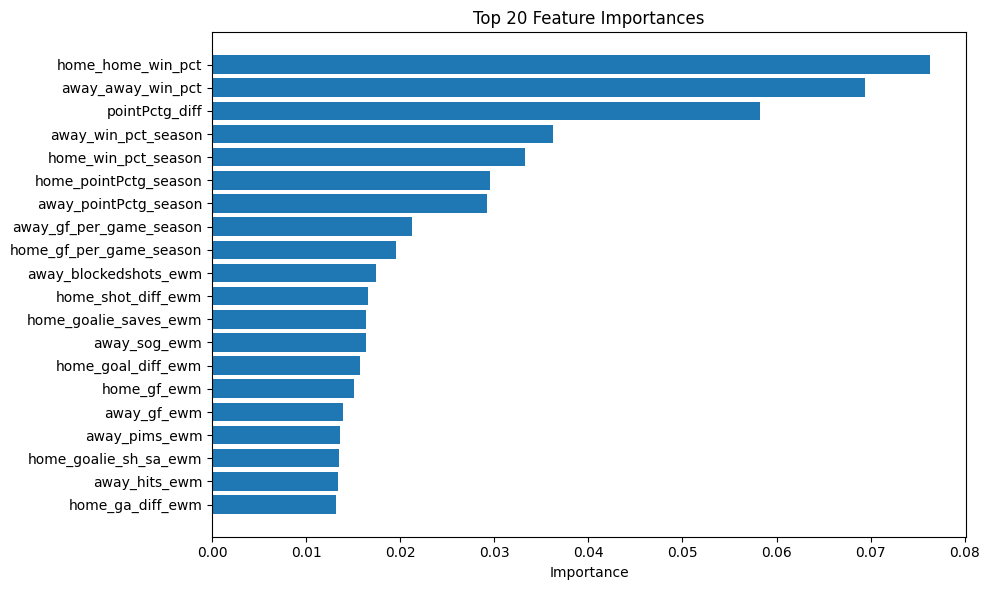

In [13]:
# =============================================================================
# FEATURE IMPORTANCE ANALYSIS
# =============================================================================

print("\n" + "="*60)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*60)

# Build dataframe
fi = pd.DataFrame({
    "feature": available_features,
    "importance": best_model.feature_importances_
}).sort_values("importance", ascending=False).head(20)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(fi["feature"][::-1], fi["importance"][::-1])
plt.title("Top 20 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()



CREATING VISUALIZATIONS


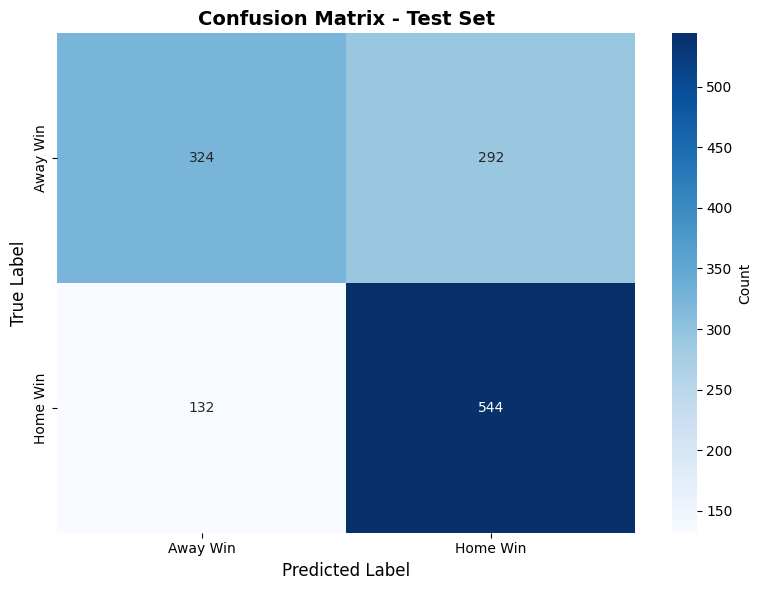

In [14]:
# =============================================================================
# 9. VISUALIZATIONS
# =============================================================================

print("\n" + "="*60)
print("CREATING VISUALIZATIONS")
print("="*60)

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Away Win', 'Home Win'],
    yticklabels=['Away Win', 'Home Win'],
    cbar_kws={'label': 'Count'}
)
plt.title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()
plt.close()

In [15]:
# =============================================================================
# 10. FINAL SUMMARY
# =============================================================================

print("\n" + "="*60)
print("FINAL MODEL SUMMARY")
print("="*60)
print(f"\nModel: Random Forest Classifier")
print(f"Features: {len(available_features)}")
print(f"\nSeason-Level Expanding Window (baseline, default params):")
print(f"  Fold 1 — Train: S1 ({len(X_s1)} games) → Test: S2 ({len(X_s2)} games): {fold1_acc:.4f}")
print(f"  Fold 2 — Train: S1+S2 ({len(X_s1s2)} games) → Test: S3 ({len(X_s3)} games): {fold2_acc:.4f}")
print(f"\nHyperparameter Tuning:")
print(f"  Tune set: S1+S2 ({len(X_tune)} games) with TimeSeriesSplit(n_splits=3)")
print(f"  Test set: S3 ({len(X_test)} games, fully held out)")
print(f"\nBest Hyperparameters:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nFinal Test Performance (S3, tuned model):")
print(f"  Accuracy: {test_accuracy:.4f}")
print("\n" + "="*60)
print("COMPLETE!")
print("="*60)


FINAL MODEL SUMMARY

Model: Random Forest Classifier
Features: 71

Season-Level Expanding Window (baseline, default params):
  Fold 1 — Train: S1 (1293 games) → Test: S2 (1292 games): 0.6904
  Fold 2 — Train: S1+S2 (2585 games) → Test: S3 (1292 games): 0.6680

Hyperparameter Tuning:
  Tune set: S1+S2 (2585 games) with TimeSeriesSplit(n_splits=3)
  Test set: S3 (1292 games, fully held out)

Best Hyperparameters:
  max_depth: 10
  min_samples_leaf: 2
  min_samples_split: 5
  n_estimators: 300

Final Test Performance (S3, tuned model):
  Accuracy: 0.6718

COMPLETE!


In [16]:
# =============================================================================
# 11. SAVE MODEL
# =============================================================================

import pickle

with open('./models/nhl_rf_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('./models/feature_names.pkl', 'wb') as f:
    pickle.dump(available_features, f)

print("\nModel saved: nhl_rf_model.pkl")
print("Features saved: feature_names.pkl")


Model saved: nhl_rf_model.pkl
Features saved: feature_names.pkl
